## 7b. XGBoost Model Training and Testing

### Setup to Load Data from S3

In [ ]:
# If you're using the default bucket, set DEFAULT_BUCKET = True; otherwise, if you're using a specific bucket, set it to False instead
DEFAULT_BUCKET = False

In [2]:
%store -r DEFAULT_BUCKET
print(DEFAULT_BUCKET)

True


In [3]:
# !pip install --upgrade pip

In [4]:
# !pip install -q PyAthena

In [3]:
import boto3
import sagemaker
import pandas as pd
from pyathena import connect
import numpy as np
sess = sagemaker.Session()
DEFAULT_BUCKET=True
bucket = sess.default_bucket()
if DEFAULT_BUCKET is False:
    # Code to use a previously existing bucket
    pub_bucket = "usdmsaai540-spring2026-team1"
s3 = boto3.resource("s3")
role = sagemaker.get_execution_role()
region = boto3.Session().region_name

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


In [4]:

# Set S3 path to Parquet data
# if DEFAULT_BUCKET:
#     s3_path_parquet = f's3://{bucket}/CCPP/data/parquet/final_data_v2'
# else:
#     s3_path_parquet = f's3://{pub_bucket}/CCPP/data//parquet'

# Set Athena parameters
database_name = "ccpp_aws_fp"
table_name_csv = "final_data_csv"
table_name_parquet = "final_data_parquet_v4"

In [5]:
# Set S3 staging directory -- this is a temporary directory used for Athena queries
s3_staging_dir = "s3://{0}/athena/staging".format(bucket)
s3_staging_dir

's3://sagemaker-us-east-1-582544415612/athena/staging'

In [6]:
conn = connect(region_name=region, s3_staging_dir=s3_staging_dir)

In [7]:
from pyathena import connect

In [8]:

statement = """SELECT count(1) FROM {}.{}
    """.format(
    database_name, table_name_parquet
)

print(statement) 

SELECT count(1) FROM ccpp_aws_fp.final_data_parquet_v4
    


In [9]:

data_count= pd.read_sql(statement, conn)
total_records=data_count['_col0'].values[0]
total_records

/tmp/ipykernel_22055/3056553487.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data_count= pd.read_sql(statement, conn)


14764

In [10]:
train_seq_id= int(total_records*0.4)
val_seq_id= train_seq_id+ int(total_records*0.4)


### Load Training Dataset (all year 2013 data)

In [11]:


statement = """SELECT * FROM {}.{}
    WHERE seq_id < {}
    ORDER BY seq_id""".format(
    database_name, table_name_parquet,train_seq_id
)

print(statement)

SELECT * FROM ccpp_aws_fp.final_data_parquet_v4
    WHERE seq_id < 5905
    ORDER BY seq_id


In [12]:
data_train = pd.read_sql(statement, conn)
data_train

/tmp/ipykernel_22055/3564220957.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data_train = pd.read_sql(statement, conn)


,seq_id,ingestion_ts,gt_comp_dis_pressure,gt_exhaust_pressure,gt_inlet_temp,gt_air_filter_diff_pressure,solar_radiation,solar_energy,uv_index,gt_ambient_pressure,cloud_cover,sea_level_pressure,gt_energy_yield
0,1,2026-02-16 22:27:20.512,10.564,19.166,1043.6,2.3927,0.0,0.0,0.0,1020.1,90.0,1023.0,110.16
1,2,2026-02-16 22:27:20.512,10.572,19.119,1039.9,2.3732,0.0,0.0,0.0,1019.9,89.0,1023.0,109.23
2,3,2026-02-16 22:27:20.512,10.543,19.178,1041.0,2.3854,0.0,0.0,0.0,1019.8,91.2,1023.1,109.62
3,4,2026-02-16 22:27:20.512,10.458,19.180,1037.1,2.3825,0.0,0.0,0.0,1019.3,90.3,1022.3,108.88
4,5,2026-02-16 22:27:20.512,10.464,19.206,1043.5,2.4044,0.0,0.0,0.0,1019.1,90.3,1022.2,110.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5899,5900,2026-02-16 22:27:20.512,11.228,22.445,1066.7,3.9474,0.0,0.0,0.0,1016.2,32.3,1022.0,123.41
5900,5901,2026-02-16 22:27:20.512,11.227,22.547,1066.6,3.9705,0.0,0.0,0.0,1016.7,0.0,1021.9,122.89
5901,5902,2026-02-16 22:27:20.512,11.354,22.764,1067.4,4.0434,0.0,0.0,0.0,1017.2,29.3,1022.0,122.73
5902,5903,2026-02-16 22:27:20.512,11.398,22.773,1067.6,4.0607,0.0,0.0,0.0,1017.4,22.2,1021.9,122.31


### Load Validation Data 2014 January

In [13]:
statement = """SELECT * FROM {}.{}
    WHERE seq_id >= {} and seq_id < {}
    ORDER BY seq_id""".format(
    database_name, table_name_parquet,train_seq_id,val_seq_id
)

print(statement)

SELECT * FROM ccpp_aws_fp.final_data_parquet_v4
    WHERE seq_id >= 5905 and seq_id < 11810
    ORDER BY seq_id


In [14]:
data_val = pd.read_sql(statement, conn)
data_val

/tmp/ipykernel_22055/3443150230.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data_val = pd.read_sql(statement, conn)


,seq_id,ingestion_ts,gt_comp_dis_pressure,gt_exhaust_pressure,gt_inlet_temp,gt_air_filter_diff_pressure,solar_radiation,solar_energy,uv_index,gt_ambient_pressure,cloud_cover,sea_level_pressure,gt_energy_yield
0,5905,2026-02-16 22:27:20.512,11.408,22.939,1067.9,4.1203,0.1,0.0,0.0,1017.3,28.1,1022.0,121.71
1,5906,2026-02-16 22:27:20.512,11.333,22.956,1067.9,4.1384,54.7,0.2,1.0,1017.0,50.0,1022.1,121.45
2,5907,2026-02-16 22:27:20.512,11.331,22.849,1068.2,4.2258,202.3,0.7,2.0,1016.6,11.9,1022.9,121.53
3,5908,2026-02-16 22:27:20.512,11.266,22.845,1068.2,4.2074,387.6,1.4,4.0,1016.2,24.7,1022.9,121.32
4,5909,2026-02-16 22:27:20.512,11.436,22.987,1068.9,4.2299,527.9,1.9,5.0,1015.8,44.0,1022.9,121.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5900,11805,2026-02-16 22:27:20.512,13.258,30.137,1099.9,4.3847,0.0,0.0,0.0,1009.9,3.6,1011.9,148.37
5901,11806,2026-02-16 22:27:20.512,13.260,30.036,1100.0,4.3804,0.0,0.0,0.0,1009.8,0.0,1011.9,148.40
5902,11807,2026-02-16 22:27:20.512,13.239,30.033,1100.0,4.3641,0.0,0.0,0.0,1009.9,3.2,1011.9,148.65
5903,11808,2026-02-16 22:27:20.512,13.104,29.681,1100.1,4.3198,0.0,0.0,0.0,1009.8,2.6,1012.0,147.88


### Load Test Data 2014 February

In [15]:
statement = """SELECT * FROM {}.{}
    WHERE seq_id >= {} 
    ORDER BY seq_id""".format(
    database_name, table_name_parquet,val_seq_id
)

print(statement)

SELECT * FROM ccpp_aws_fp.final_data_parquet_v4
    WHERE seq_id >= 11810 
    ORDER BY seq_id


In [16]:
data_test = pd.read_sql(statement, conn)
data_test

/tmp/ipykernel_22055/2304454054.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data_test = pd.read_sql(statement, conn)


,seq_id,ingestion_ts,gt_comp_dis_pressure,gt_exhaust_pressure,gt_inlet_temp,gt_air_filter_diff_pressure,solar_radiation,solar_energy,uv_index,gt_ambient_pressure,cloud_cover,sea_level_pressure,gt_energy_yield
0,11810,2026-02-16 22:27:20.512,13.118,29.805,1099.9,4.3594,0.0,0.0,0.0,1010.2,0.0,1011.9,147.21
1,11811,2026-02-16 22:27:20.512,13.160,30.018,1099.9,4.4136,0.0,0.0,0.0,1010.3,1.0,1011.9,147.14
2,11812,2026-02-16 22:27:20.512,13.204,30.199,1099.9,4.4296,0.0,0.0,0.0,1010.3,0.0,1012.0,147.66
3,11813,2026-02-16 22:27:20.512,13.121,29.979,1099.9,4.3978,19.9,0.1,0.0,1010.2,0.0,1012.0,147.14
4,11814,2026-02-16 22:27:20.512,13.094,29.712,1100.0,4.3754,144.2,0.5,1.0,1009.8,0.0,1010.5,146.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2950,14760,2026-02-16 22:27:20.512,10.411,19.087,1037.0,3.1661,0.0,0.0,0.0,1028.5,78.2,1029.6,109.08
2951,14761,2026-02-16 22:27:20.512,10.344,19.016,1037.6,3.1923,0.0,0.0,0.0,1028.6,78.2,1028.8,108.79
2952,14762,2026-02-16 22:27:20.512,10.462,18.857,1038.0,3.3128,0.0,0.0,0.0,1028.5,46.0,1028.7,107.81
2953,14763,2026-02-16 22:27:20.512,11.771,23.563,1076.9,3.9831,0.0,0.0,0.0,1028.7,46.0,1028.7,131.41


### Prepare the dataset

In [17]:
data_train = data_train.drop(['seq_id', 'ingestion_ts'], axis=1)
data_train

,gt_comp_dis_pressure,gt_exhaust_pressure,gt_inlet_temp,gt_air_filter_diff_pressure,solar_radiation,solar_energy,uv_index,gt_ambient_pressure,cloud_cover,sea_level_pressure,gt_energy_yield
0,10.564,19.166,1043.6,2.3927,0.0,0.0,0.0,1020.1,90.0,1023.0,110.16
1,10.572,19.119,1039.9,2.3732,0.0,0.0,0.0,1019.9,89.0,1023.0,109.23
2,10.543,19.178,1041.0,2.3854,0.0,0.0,0.0,1019.8,91.2,1023.1,109.62
3,10.458,19.180,1037.1,2.3825,0.0,0.0,0.0,1019.3,90.3,1022.3,108.88
4,10.464,19.206,1043.5,2.4044,0.0,0.0,0.0,1019.1,90.3,1022.2,110.09
...,...,...,...,...,...,...,...,...,...,...,...
5899,11.228,22.445,1066.7,3.9474,0.0,0.0,0.0,1016.2,32.3,1022.0,123.41
5900,11.227,22.547,1066.6,3.9705,0.0,0.0,0.0,1016.7,0.0,1021.9,122.89
5901,11.354,22.764,1067.4,4.0434,0.0,0.0,0.0,1017.2,29.3,1022.0,122.73
5902,11.398,22.773,1067.6,4.0607,0.0,0.0,0.0,1017.4,22.2,1021.9,122.31


In [26]:
data_val = data_val.drop(['seq_id', 'ingestion_ts'], axis=1)
data_val

,gt_comp_dis_pressure,gt_exhaust_pressure,gt_inlet_temp,gt_air_filter_diff_pressure,solar_radiation,solar_energy,uv_index,gt_ambient_pressure,cloud_cover,sea_level_pressure,gt_energy_yield
0,11.408,22.939,1067.9,4.1203,0.1,0.0,0.0,1017.3,28.1,1022.0,121.71
1,11.333,22.956,1067.9,4.1384,54.7,0.2,1.0,1017.0,50.0,1022.1,121.45
2,11.331,22.849,1068.2,4.2258,202.3,0.7,2.0,1016.6,11.9,1022.9,121.53
3,11.266,22.845,1068.2,4.2074,387.6,1.4,4.0,1016.2,24.7,1022.9,121.32
4,11.436,22.987,1068.9,4.2299,527.9,1.9,5.0,1015.8,44.0,1022.9,121.70
...,...,...,...,...,...,...,...,...,...,...,...
5900,13.258,30.137,1099.9,4.3847,0.0,0.0,0.0,1009.9,3.6,1011.9,148.37
5901,13.260,30.036,1100.0,4.3804,0.0,0.0,0.0,1009.8,0.0,1011.9,148.40
5902,13.239,30.033,1100.0,4.3641,0.0,0.0,0.0,1009.9,3.2,1011.9,148.65
5903,13.104,29.681,1100.1,4.3198,0.0,0.0,0.0,1009.8,2.6,1012.0,147.88


In [18]:
data_test = data_test.drop(['seq_id', 'ingestion_ts'], axis=1)
data_test

,gt_comp_dis_pressure,gt_exhaust_pressure,gt_inlet_temp,gt_air_filter_diff_pressure,solar_radiation,solar_energy,uv_index,gt_ambient_pressure,cloud_cover,sea_level_pressure,gt_energy_yield
0,13.118,29.805,1099.9,4.3594,0.0,0.0,0.0,1010.2,0.0,1011.9,147.21
1,13.160,30.018,1099.9,4.4136,0.0,0.0,0.0,1010.3,1.0,1011.9,147.14
2,13.204,30.199,1099.9,4.4296,0.0,0.0,0.0,1010.3,0.0,1012.0,147.66
3,13.121,29.979,1099.9,4.3978,19.9,0.1,0.0,1010.2,0.0,1012.0,147.14
4,13.094,29.712,1100.0,4.3754,144.2,0.5,1.0,1009.8,0.0,1010.5,146.55
...,...,...,...,...,...,...,...,...,...,...,...
2950,10.411,19.087,1037.0,3.1661,0.0,0.0,0.0,1028.5,78.2,1029.6,109.08
2951,10.344,19.016,1037.6,3.1923,0.0,0.0,0.0,1028.6,78.2,1028.8,108.79
2952,10.462,18.857,1038.0,3.3128,0.0,0.0,0.0,1028.5,46.0,1028.7,107.81
2953,11.771,23.563,1076.9,3.9831,0.0,0.0,0.0,1028.7,46.0,1028.7,131.41


In [22]:
data_batch = data_test.drop(['gt_energy_yield'], axis=1)
data_batch

,gt_comp_dis_pressure,gt_exhaust_pressure,gt_inlet_temp,gt_air_filter_diff_pressure,solar_radiation,solar_energy,uv_index,gt_ambient_pressure,cloud_cover,sea_level_pressure
0,13.118,29.805,1099.9,4.3594,0.0,0.0,0.0,1010.2,0.0,1011.9
1,13.160,30.018,1099.9,4.4136,0.0,0.0,0.0,1010.3,1.0,1011.9
2,13.204,30.199,1099.9,4.4296,0.0,0.0,0.0,1010.3,0.0,1012.0
3,13.121,29.979,1099.9,4.3978,19.9,0.1,0.0,1010.2,0.0,1012.0
4,13.094,29.712,1100.0,4.3754,144.2,0.5,1.0,1009.8,0.0,1010.5
...,...,...,...,...,...,...,...,...,...,...
2950,10.411,19.087,1037.0,3.1661,0.0,0.0,0.0,1028.5,78.2,1029.6
2951,10.344,19.016,1037.6,3.1923,0.0,0.0,0.0,1028.6,78.2,1028.8
2952,10.462,18.857,1038.0,3.3128,0.0,0.0,0.0,1028.5,46.0,1028.7
2953,11.771,23.563,1076.9,3.9831,0.0,0.0,0.0,1028.7,46.0,1028.7


In [27]:
prefix = "CCPP-enery-prediction-xgb-regression"

In [28]:
s3 = boto3.client("s3")

train_file = "train_data.csv"
#data_train.to_csv(train_file, index=False, header=False)
df=data_train.copy()
cols = df.columns.tolist()
df = df[[cols[-1]] + cols[:-1]]
df.to_csv(train_file, index=False, header=False)
#sess.upldfoad_data(train_file, key_prefix="{}/train".format(prefix))
s3.upload_file(train_file, bucket, "{}/train/{}".format(prefix,train_file))


validation_file = "validation_data.csv"
#data_val.to_csv(validation_file, index=False, header=False)
df=data_val.copy()
cols = df.columns.tolist()
df = df[[cols[-1]] + cols[:-1]]
df.to_csv(validation_file, index=False, header=False)
#sess.upload_data(validation_file, key_prefix="{}/validation".format(prefix))
s3.upload_file(validation_file, bucket, "{}/validation/{}".format(prefix,validation_file))

test_file = "test_data.csv"
df=data_test.copy()
cols = df.columns.tolist()
df = df[[cols[-1]] + cols[:-1]]
df.to_csv(test_file, index=False, header=False)
#sess.upload_data(test_file, key_prefix="{}/test".format(prefix))
s3.upload_file(test_file, bucket, "{}/testing/{}".format(prefix,test_file))

batch_file = "batch_data.csv"
df=data_batch.copy()
df.to_csv(batch_file, index=False, header=False)#sess.upload_data(batch_file, key_prefix="{}/batch".format(prefix))
s3.upload_file(batch_file, bucket, "{}/batch/{}".format(prefix,batch_file))


In [29]:
data_train

,gt_comp_dis_pressure,gt_exhaust_pressure,gt_inlet_temp,gt_air_filter_diff_pressure,solar_radiation,solar_energy,uv_index,gt_ambient_pressure,cloud_cover,sea_level_pressure,gt_energy_yield
0,10.564,19.166,1043.6,2.3927,0.0,0.0,0.0,1020.1,90.0,1023.0,110.16
1,10.572,19.119,1039.9,2.3732,0.0,0.0,0.0,1019.9,89.0,1023.0,109.23
2,10.543,19.178,1041.0,2.3854,0.0,0.0,0.0,1019.8,91.2,1023.1,109.62
3,10.458,19.180,1037.1,2.3825,0.0,0.0,0.0,1019.3,90.3,1022.3,108.88
4,10.464,19.206,1043.5,2.4044,0.0,0.0,0.0,1019.1,90.3,1022.2,110.09
...,...,...,...,...,...,...,...,...,...,...,...
5899,11.228,22.445,1066.7,3.9474,0.0,0.0,0.0,1016.2,32.3,1022.0,123.41
5900,11.227,22.547,1066.6,3.9705,0.0,0.0,0.0,1016.7,0.0,1021.9,122.89
5901,11.354,22.764,1067.4,4.0434,0.0,0.0,0.0,1017.2,29.3,1022.0,122.73
5902,11.398,22.773,1067.6,4.0607,0.0,0.0,0.0,1017.4,22.2,1021.9,122.31


In [56]:
batch_file = "batch_data.csv"
df=data_batch.copy()
df.to_csv(train_file, index=False, header=False)#sess.upload_data(batch_file, key_prefix="{}/batch".format(prefix))
s3.upload_file(train_file, bucket, "{}/batch/{}".format(prefix,batch_file))


### Model Training Setup and Training

In [57]:
%%time
from time import gmtime, strftime

job_name = "xgb-" + strftime("%Y-%m-%d-%H-%M-%S", gmtime())
output_location = "s3://{}/{}/output/{}".format(bucket, prefix, job_name)
image = sagemaker.image_uris.retrieve(
    framework="xgboost",
    region=boto3.Session().region_name,
    version="1.7-1"
)

xgb_estimator = sagemaker.estimator.Estimator(
    image_uri=image,
    role=role,
    instance_count=1,
    instance_type="ml.m5.large",
    volume_size=50,
    input_mode="File",
    output_path=output_location,
    sagemaker_session=sess,
)

xgb_estimator.set_hyperparameters(
    objective="reg:squarederror",
    num_round=200,
    max_depth=6,
    eta=0.1,
)
train_data = sagemaker.inputs.TrainingInput(
    "s3://{}/{}/train".format(bucket, prefix),
    distribution="FullyReplicated",
    content_type="text/csv",
    s3_data_type="S3Prefix",
)
validation_data = sagemaker.inputs.TrainingInput(
    "s3://{}/{}/validation".format(bucket, prefix),
    distribution="FullyReplicated",
    content_type="text/csv",
    s3_data_type="S3Prefix",
)
data_channels = {"train": train_data, "validation": validation_data}

# Start training by calling the fit method in the estimator
xgb_estimator.fit(inputs=data_channels, job_name=job_name, logs=True)


INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker:Creating training-job with name: xgb-2026-02-16-23-26-41


2026-02-16 23:26:42 Starting - Starting the training job...
2026-02-16 23:26:57 Starting - Preparing the instances for training...
2026-02-16 23:27:19 Downloading - Downloading input data...
2026-02-16 23:27:59 Downloading - Downloading the training image......
2026-02-16 23:29:16 Training - Training image download completed. Training in progress.
2026-02-16 23:29:16 Uploading - Uploading generated training model/miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-02-16 23:29:08.129 ip-10-0-190-184.ec2.internal:6 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-02-16 23:29:08.205 ip-10-0-190-184.ec2.internal:6 INFO profiler_config_parser.py:111] User has disabled profiler.
[2026-02-16:2

In [58]:
batch_file = "batch_data.csv"
df=data_batch.copy()
df.to_csv(train_file, index=False, header=False)#sess.upload_data(batch_file, key_prefix="{}/batch".format(prefix))
s3.upload_file(train_file, bucket, "{}/batch/{}".format(prefix,batch_file))


In [59]:
print( "{}/batch/{}".format(prefix,batch_file))

CCPP-enery-prediction-xgb-regression/batch/batch_data.csv


In [60]:
xgb_estimator.output_path

's3://sagemaker-us-east-1-582544415612/CCPP-enery-prediction-xgb-regression/output/xgb-2026-02-16-23-26-41'

### Setup Batch Transfomer Estimator

In [61]:
%%time

xgb_transformer = xgb_estimator.transformer(1, "ml.m5.xlarge")

# start a transform job
input_location = "s3://{}/{}/batch".format(
    bucket, prefix
)  
xgb_transformer.transform(input_location, content_type="text/csv", split_type="Line")
xgb_transformer.wait()

INFO:sagemaker:Creating model with name: sagemaker-xgboost-2026-02-16-23-29-58-796
INFO:sagemaker:Creating transform job with name: sagemaker-xgboost-2026-02-16-23-29-59-583


.................................
/miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-02-16:23:35:31:INFO] No GPUs detected (normal if no gpus installed)
[2026-02-16:23:35:31:INFO] No GPUs detected (normal if no gpus installed)
[2026-02-16:23:35:31:INFO] nginx config: 
worker_processes auto;
daemon off;
pid /tmp/nginx.pid;
error_log  /dev/stderr;
worker_rlimit_nofile 4096;
events {
  worker_connections 2048;
}
http {
  include /etc/nginx/mime.types;
  default_type application/octet-stream;
  access_log /dev/stdout combined;
  upstream gunicorn {
    server unix:/tmp/gunicorn.sock;
  }
  server {
    listen 8080 deferred;
    client_max_body_size 0;
    keepalive_timeout 3;
    location ~ ^/(ping|

In [62]:
xgb_transformer.output_path

's3://sagemaker-us-east-1-582544415612/sagemaker-xgboost-2026-02-16-23-29-59-583'

In [63]:
! aws s3 ls   s3://sagemaker-us-east-1-582544415612/linear-learner-2026-02-15-21-46-38-592/

2026-02-15 21:51:51      83637 batch_data.csv.out


In [64]:
!aws s3 cp 's3://sagemaker-us-east-1-582544415612/linear-learner-2026-02-15-21-46-38-592/batch_data.csv.out' .

download: s3://sagemaker-us-east-1-582544415612/linear-learner-2026-02-15-21-46-38-592/batch_data.csv.out to ./batch_data.csv.out


### Plot the Batch Transform Result Compare to Ground Truth

In [65]:
import re


def get_csv_output_from_s3(s3uri, batch_file):
    file_name = "{}.out".format(batch_file)
    match = re.match("s3://([^/]+)/(.*)", "{}/{}".format(s3uri, file_name))
    output_bucket, output_prefix = match.group(1), match.group(2)
    s3.download_file(output_bucket, output_prefix, file_name)
    return pd.read_csv(file_name, sep=",", header=None)

In [66]:
s3 = boto3.client("s3")

In [67]:
output_df = get_csv_output_from_s3(xgb_transformer.output_path, batch_file)
output_df.head(8)

,0
0,148.511932
1,148.930649
2,150.119125
3,148.315613
4,147.982590
5,146.779541
6,149.500153
7,150.752625


In [68]:
compare_df = data_test[['gt_energy_yield']]

In [69]:
compare_df

,gt_energy_yield
0,147.21
1,147.14
2,147.66
3,147.14
4,146.55
...,...
2950,109.08
2951,108.79
2952,107.81
2953,131.41


In [70]:
combined_df = pd.concat([compare_df, output_df[0]], axis=1)

In [71]:
combined_df

,gt_energy_yield,0
0,147.21,148.511932
1,147.14,148.930649
2,147.66,150.119125
3,147.14,148.315613
4,146.55,147.982590
...,...,...
2950,109.08,107.651428
2951,108.79,107.814835
2952,107.81,107.304657
2953,131.41,132.480682


In [72]:
combined_df.rename(columns={0: 'Predited Energy'}, inplace=True)

In [73]:
combined_df

,gt_energy_yield,Predited Energy
0,147.21,148.511932
1,147.14,148.930649
2,147.66,150.119125
3,147.14,148.315613
4,146.55,147.982590
...,...,...
2950,109.08,107.651428
2951,108.79,107.814835
2952,107.81,107.304657
2953,131.41,132.480682


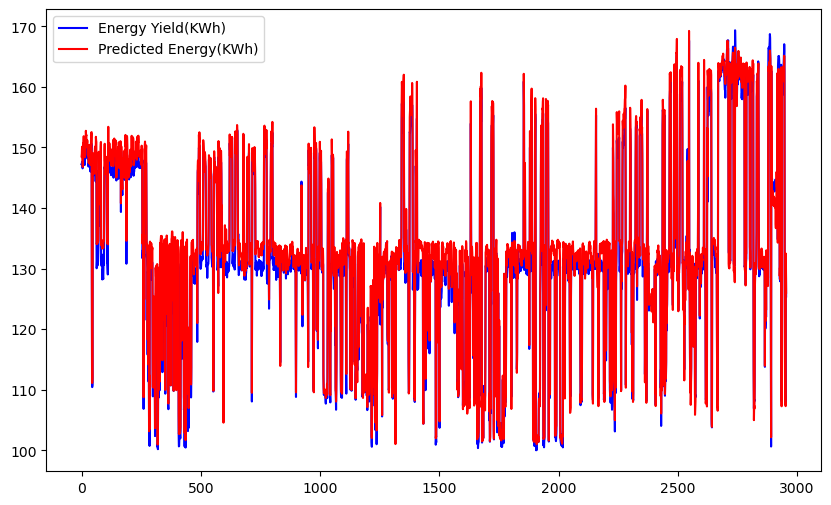

In [74]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

# Plotting the first column with a solid line
plt.plot(combined_df.index, combined_df['gt_energy_yield'], color='blue', label='Energy Yield(KWh)')

# Plotting the second column with a dotted line
plt.plot(combined_df.index, combined_df['Predited Energy'], color='red', label='Predicted Energy(KWh)')
plt.legend()
# Show plot
plt.show()

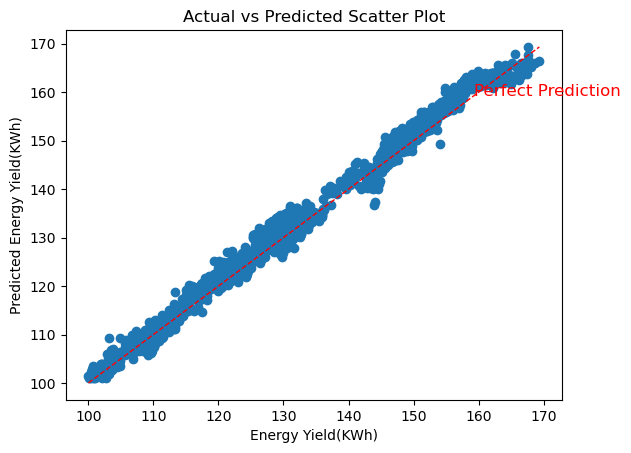

In [75]:
plt.figure()
plt.scatter(combined_df['gt_energy_yield'], combined_df['Predited Energy'])
y_test=combined_df['gt_energy_yield']
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1)
plt.text(y_test.max()-10, y_test.max()-10, 'Perfect Prediction', color='red', fontsize=12)    
plt.xlabel("Energy Yield(KWh)")
plt.ylabel("Predicted Energy Yield(KWh)")
plt.title("Actual vs Predicted Scatter Plot")

plt.show()

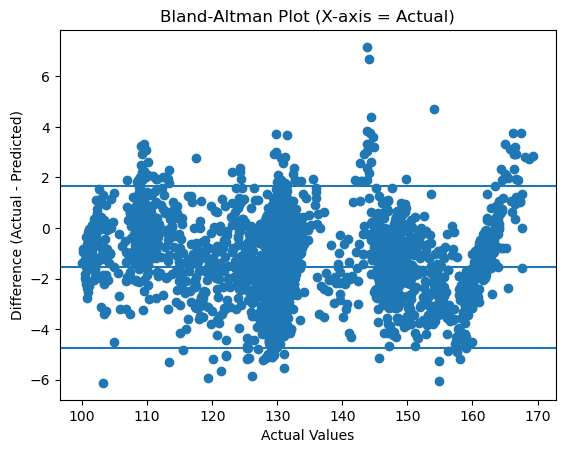

In [76]:
import numpy as np
differences = combined_df['gt_energy_yield']-combined_df['Predited Energy']

mean_diff = np.mean(differences)
std_diff = np.std(differences)

upper_limit = mean_diff + 1.96 * std_diff
lower_limit = mean_diff - 1.96 * std_diff

# Plot
plt.figure()
plt.scatter(combined_df['gt_energy_yield'], differences)

plt.axhline(mean_diff)
plt.axhline(upper_limit)
plt.axhline(lower_limit)

plt.xlabel("Actual Values")
plt.ylabel("Difference (Actual - Predicted)")
plt.title("Bland-Altman Plot (X-axis = Actual)")

plt.show()

In [77]:
xgb_estimator.model_data

's3://sagemaker-us-east-1-582544415612/CCPP-enery-prediction-xgb-regression/output/xgb-2026-02-16-23-26-41/xgb-2026-02-16-23-26-41/output/model.tar.gz'

In [78]:
%%html

<p><b>Shutting down your kernel for this notebook to release resources.</b></p>
<button class="sm-command-button" data-commandlinker-command="kernelmenu:shutdown" style="display:none;">Shutdown Kernel</button>
        
<script>
try {
    els = document.getElementsByClassName("sm-command-button");
    els[0].click();
}
catch(err) {
    // NoOp
}    
</script>